# 전후각(Pitch Angle) 기반 달력 이미지 크기 분석

**목적**: 카메라 전후각(-10°, -1°, +6°) 변화에 따라 달력의 픽셀 높이가 어떻게 달라지는지 분석하고,
보정 함수(`pitch_correction.py`)를 검증한다.

## 수학 모델

카메라가 달력보다 위에 위치한 비대칭 셋업에서:

$$h(\theta) = \frac{K}{\cos(\alpha_{top} + \theta) \cdot \cos(\alpha_{bot} + \theta)}$$

- $\theta$: 카메라 전후각 (라디안)
- $\alpha_{top}$: 카메라 → 달력 상단 수직 시각 (하향 음수)
- $\alpha_{bot}$: 카메라 → 달력 하단 수직 시각 (하향 음수, $\alpha_{bot} < \alpha_{top}$)
- $K$: 스케일 상수

보정 스케일: $\text{scale}(\theta) = h(\theta_{ref}) / h(\theta)$

In [32]:
import sys
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# pitch_correction 모듈 경로 추가
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from pitch_correction import (
    PitchCorrectionModel,
    correct_image_size,
    measure_calendar_height,
)

# 이미지 경로
IMG_DIR = 'images'
IMAGE_FILES = {
    -10: os.path.join(IMG_DIR, 'test_20260304_GRD_-10degree.jpg'),
     -1: os.path.join(IMG_DIR, 'test_20260304_GRD_-1degree.jpg'),
      6: os.path.join(IMG_DIR, 'test_20260304_GRD_6degree.jpg'),
}
ANGLES = [-10, -1, 6]
REF_ANGLE = -1   # 보정 기준 각도 (가장 작게 보이는 각도)

print('Libraries loaded.')
print(f'HAS_SCIPY: {__import__("pitch_correction").HAS_SCIPY}')

Libraries loaded.
HAS_SCIPY: False


## Cell 3: 이미지 로드 및 시각화

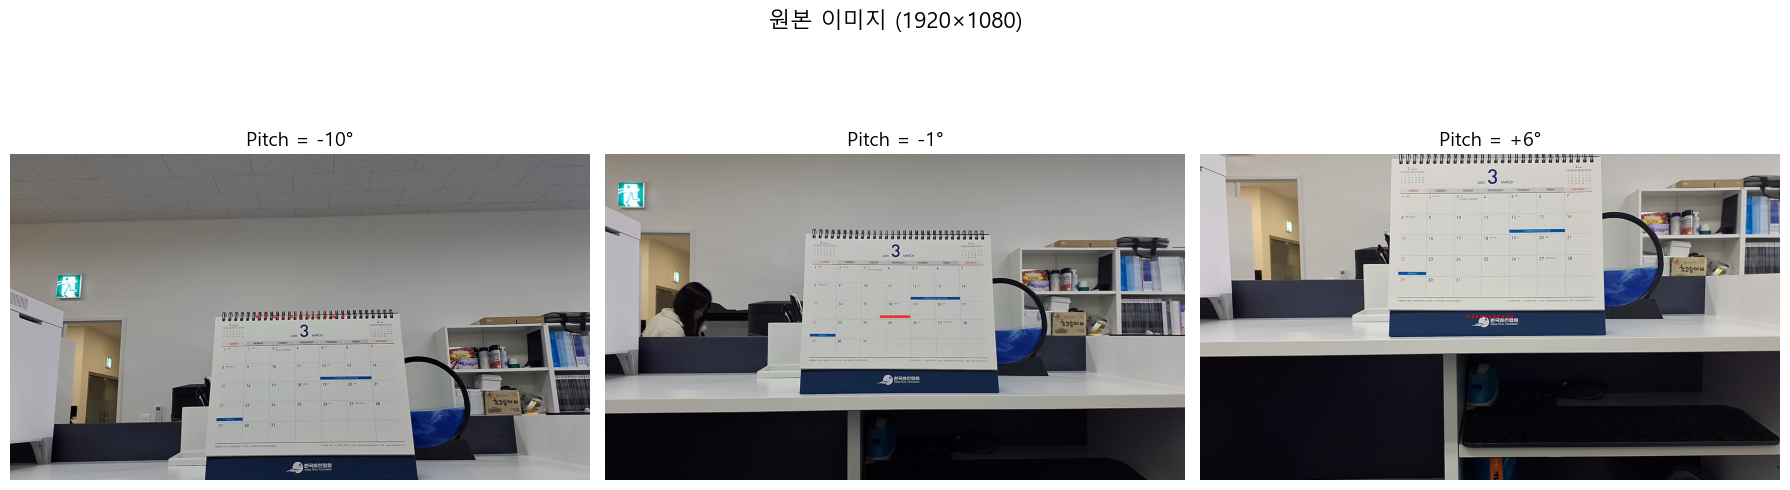

Images loaded: {-10: (1080, 1920, 3), -1: (1080, 1920, 3), 6: (1080, 1920, 3)}


In [33]:
images = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, angle in zip(axes, ANGLES):
    path = IMAGE_FILES[angle]
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f'Cannot load: {path}')
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    images[angle] = img_bgr
    ax.imshow(img_rgb)
    ax.set_title(f'Pitch = {angle:+d}°', fontsize=14)
    ax.axis('off')

plt.suptitle('원본 이미지 (1920×1080)', fontsize=16)
plt.tight_layout()
plt.show()
print('Images loaded:', {a: images[a].shape for a in ANGLES})

## Cell 4: 달력 Bounding Box 측정

자동 감지 → 실패 시 수동 폴백 값 사용.

Pitch -10°  top=516  bot=767  h=251px  w_top=1216  w_bot=1337  ratio=0.909
Pitch  -1°  top=250  bot=416  h=166px  w_top=568  w_bot=1153  ratio=0.493
Pitch  +6°  top=0  bot=197  h=197px  w_top=692  w_bot=1288  ratio=0.537


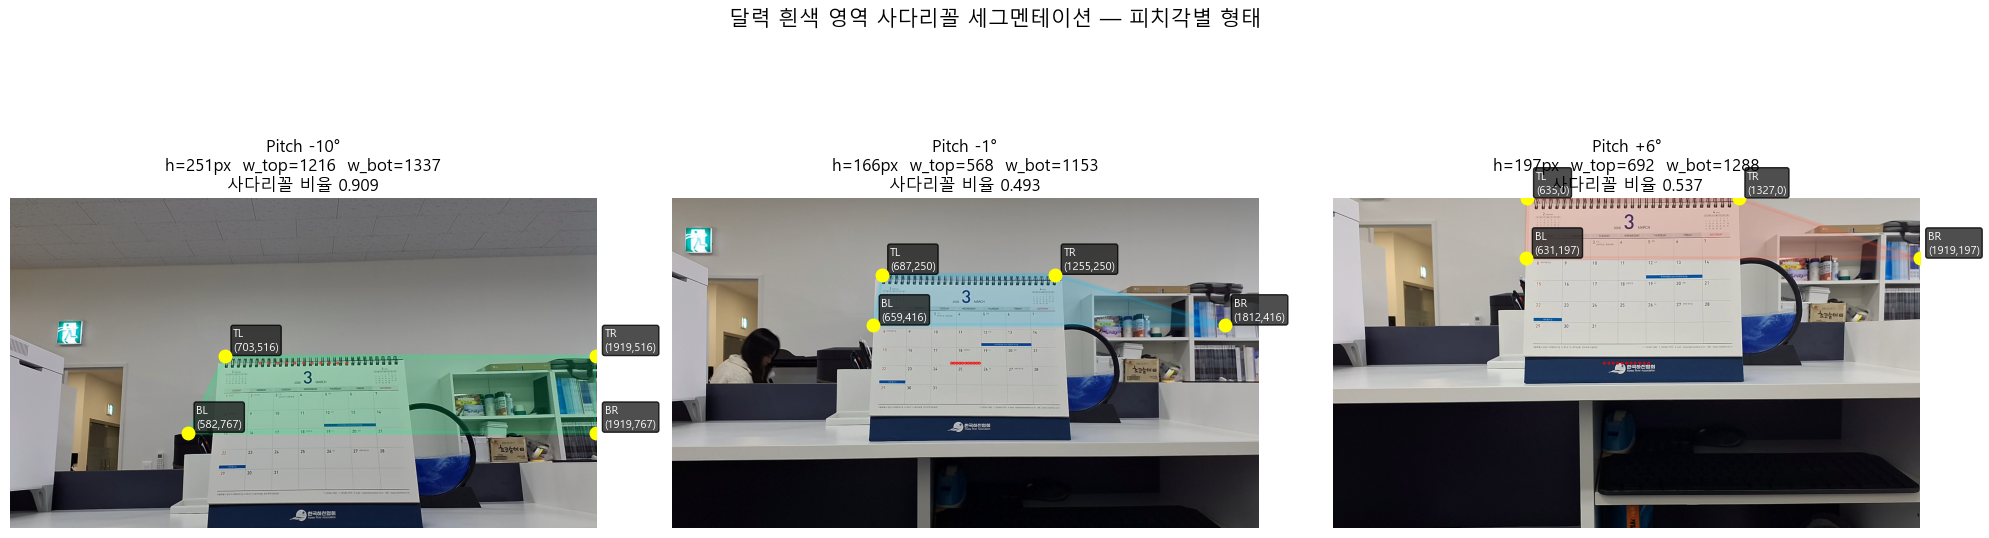

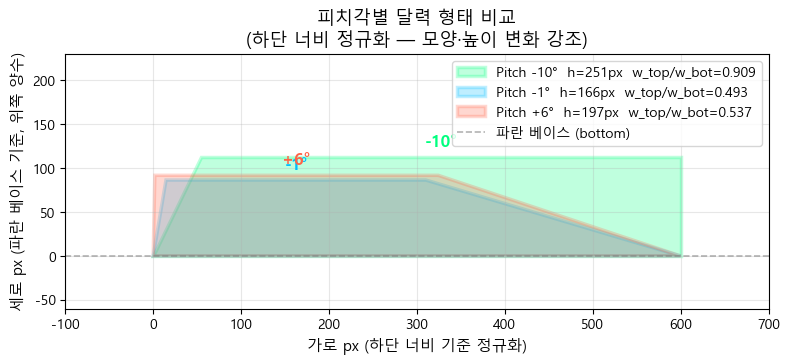


   각도   top_y   bot_y    h(px)   w_top   w_bot   w_top/w_bot
------------------------------------------------------------
  -10°     516     767      251    1216    1337         0.909
   -1°     250     416      166     568    1153         0.493 ← REF
   +6°       0     197      197     692    1288         0.537


In [35]:
# ── Cell 5: 달력 사다리꼴 세그멘테이션 & 피치각별 형태 비교 ──
# 목적: 피치각(-10°, -1°, +6°)에 따라 달력이 어떤 모양(직사각형/사다리꼴)으로
#        찍히는지 4점 폴리곤으로 세그멘테이션하여 형태 변환을 분석한다.
#
# 감지 알고리즘:
#   ① 파란 베이스(navy blue frame) → bottom_y 및 좌우 열 범위
#   ② 흰색 마스크(HSV S<55 V>175) + 열 범위 → 배경 벽면 제외
#   ③ 모폴로지 클로징 → 격자선·숫자 공백 채우기
#   ④ 연결 컴포넌트 시드 from bottom_y → 달력 blob 추출
#   ⑤ 상단/하단 10% 밴드의 좌우 극값 → 4점 사다리꼴(tl, tr, br, bl)

import importlib, pitch_correction as _pc
importlib.reload(_pc)
from matplotlib.patches import Polygon as MplPolygon

import cv2
import numpy as np

def segment_calendar_quad(image):
    """
    달력 흰색 영역을 4점 사다리꼴로 세그멘테이션 (엣지 검출 및 모폴로지 결합 방식)
    """
    H, W = image.shape[:2]
    
    # ① 파란색 스탠드(베이스) 찾기 (확실한 기준점)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # 조명 반사나 어두운 그림자를 고려해 파란색 범위를 여유있게 잡습니다.
    lower_blue = np.array([90, 40, 20])
    upper_blue = np.array([130, 255, 255])
    blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # 노이즈 제거
    blue_mask = cv2.morphologyEx(blue_mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (15, 5)))
    
    cnts, _ = cv2.findContours(blue_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blue_rects = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        # 조건: 가로로 길고, 일정 크기 이상이며 화면 중앙부에 위치
        if w > h * 2.0 and w > W * 0.15 and W * 0.2 < (x + w/2) < W * 0.8:
            blue_rects.append((w*h, x, y, w, h))
            
    if not blue_rects:
        return None, None # 기준점이 될 파란 베이스를 찾지 못함

    # 가장 큰 파란 영역을 베이스로 선정
    _, bx, by, bw, bh = max(blue_rects)
    bottom_y = by  # 달력 종이의 실질적인 하단 한계선

    # ② 하얀색 달력 종이 영역 찾기 (엣지 검출 활용)
    # 배경 벽과 달력을 구분하기 위해 Canny Edge Detection 사용
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 40, 120)

    # 파란 베이스 크기를 바탕으로 탐색 영역(ROI) 제한 (좌우 책장, 문 등 배경 노이즈 완전 차단)
    # +6도 Pitch에서 위쪽이 넓어질 수 있으므로 좌우로 25% 여유 공간(margin) 부여
    margin = int(bw * 0.25)
    roi_l = max(0, bx - margin)
    roi_r = min(W, bx + bw + margin)
    
    roi_mask = np.zeros_like(edges)
    roi_mask[:bottom_y, roi_l:roi_r] = edges[:bottom_y, roi_l:roi_r]

    # ③ 엣지들을 크게 팽창(Close)시켜 달력 내부(글자, 선)와 외곽선을 하나의 덩어리로 연결
    kernel_w = max(10, bw // 6)
    kernel_h = max(10, H // 25)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_w, kernel_h))
    connected = cv2.morphologyEx(roi_mask, cv2.MORPH_CLOSE, kernel)

    # 덩어리(컨투어) 찾기
    cnts, _ = cv2.findContours(connected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None, None

    # 파란 베이스(bottom_y) 바로 위에 얹혀있는 가장 큰 덩어리를 달력 종이로 간주
    best_cnt = None
    max_area = 0
    for c in cnts:
        cx, cy, cw, ch = cv2.boundingRect(c)
        # 컨투어의 하단(cy+ch)이 파란 베이스(bottom_y)에 충분히 가까운지 확인
        if (cy + ch) > bottom_y - (H // 8):
            area = cv2.contourArea(c)
            if area > max_area:
                max_area = area
                best_cnt = c

    if best_cnt is None:
        return None, None

    # ④ 4개의 꼭짓점(사다리꼴) 추출
    cx, cy, cw, ch = cv2.boundingRect(best_cnt)
    top_y = cy

    # 정확한 좌우 폭 측정을 위해 마스크에 컨투어 칠하기
    paper_mask = np.zeros_like(gray)
    cv2.drawContours(paper_mask, [best_cnt], -1, 255, -1)

    # 상단/하단 측정용 밴드(Band) 높이 설정 (전체 높이의 약 10%)
    band_h = max(5, ch // 12)

    # 상단 끝점 찾기
    top_band = paper_mask[top_y:top_y+band_h, :]
    ys, xs = np.where(top_band > 0)
    if len(xs) == 0: return None, None
    tl = (int(xs.min()), top_y)
    tr = (int(xs.max()), top_y)

    # 하단 끝점 찾기 (파란 베이스 바로 위쪽)
    bot_y_start = max(0, bottom_y - band_h)
    bot_band = paper_mask[bot_y_start:bottom_y, :]
    ys, xs = np.where(bot_band > 0)
    
    if len(xs) == 0:
        bl = (bx, bottom_y)
        br = (bx + bw, bottom_y)
    else:
        bl = (int(xs.min()), bottom_y)
        br = (int(xs.max()), bottom_y)

    quad = np.array([tl, tr, br, bl])
    
    h_px  = bottom_y - top_y
    w_top = tr[0] - tl[0]
    w_bot = br[0] - bl[0]
    
    return quad, (top_y, bottom_y, h_px, w_top, w_bot)


# ── 세 이미지에 적용 ──
MANUAL_BOUNDS = {
    -10: (554, 1001, 447),
     -1: (286,  573, 287),
      6: ( 34,  521, 487),
}
quads     = {}
quad_info = {}

for angle in ANGLES:
    q, info = segment_calendar_quad(images[angle])
    quads[angle]     = q
    quad_info[angle] = info
    if info:
        t, b, h, wt, wb = info
        print(f'Pitch {angle:+3d}°  top={t}  bot={b}  h={h}px  '
              f'w_top={wt}  w_bot={wb}  ratio={wt/wb:.3f}')
    else:
        print(f'Pitch {angle:+3d}°  감지 실패 → MANUAL 폴백')

# downstream용 bounds / heights_px
bounds = {}
for angle in ANGLES:
    if quad_info[angle]:
        t, b, h, *_ = quad_info[angle]
        bounds[angle] = (t, b, h)
    else:
        bounds[angle] = MANUAL_BOUNDS[angle]
heights_px = [bounds[a][2] for a in ANGLES]

# ── ① 피치각별 사다리꼴 오버레이 ──
COLORS = {-10: '#00FF7F', -1: '#00BFFF', 6: '#FF6347'}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, angle in zip(axes, ANGLES):
    ax.imshow(cv2.cvtColor(images[angle], cv2.COLOR_BGR2RGB))
    q = quads[angle]
    if q is not None:
        ax.add_patch(MplPolygon(q, closed=True, linewidth=3,
                                edgecolor=COLORS[angle],
                                facecolor=COLORS[angle], alpha=0.18))
        for (x, y), lbl in zip(q, ['TL', 'TR', 'BR', 'BL']):
            ax.plot(x, y, 'o', color='yellow', ms=9, zorder=5)
            ax.annotate(f'{lbl}\n({x},{y})', (x, y),
                        textcoords='offset points', xytext=(6, 4),
                        fontsize=8, color='white',
                        bbox=dict(boxstyle='round,pad=0.2',
                                  facecolor='#222', alpha=0.8))
        t, b, h, wt, wb = quad_info[angle]
        title = (f'Pitch {angle:+d}°\n'
                 f'h={h}px  w_top={wt}  w_bot={wb}\n'
                 f'사다리꼴 비율 {wt/wb:.3f}')
    else:
        title = f'Pitch {angle:+d}°\n감지 실패'
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.suptitle('달력 흰색 영역 사다리꼴 세그멘테이션 — 피치각별 형태', fontsize=15)
plt.tight_layout()
plt.show()

# ── ② 정규화 형태 비교 (3개 사다리꼴을 동일 캔버스에 오버레이) ──
fig2, ax2 = plt.subplots(figsize=(8, 7))
REF_W = 600   # 정규화 기준 너비 (임의)

y_max = 0
for angle in ANGLES:
    info = quad_info[angle]
    if info and info[4] > 0:
        y_max = max(y_max, info[2] * REF_W / info[4])

for angle in ANGLES:
    q = quads[angle]
    if q is None:
        continue
    t, b, h, wt, wb = quad_info[angle]
    sc = REF_W / wb if wb > 0 else 1.0

    # bl 꼭짓점을 원점으로, 위쪽이 양수
    ox, oy = float(q[3, 0]), float(b)
    q_n = np.zeros_like(q, dtype=float)
    q_n[:, 0] = (q[:, 0] - ox) * sc
    q_n[:, 1] = -(q[:, 1] - oy) * sc

    ax2.add_patch(MplPolygon(q_n, closed=True, linewidth=2.5,
                              edgecolor=COLORS[angle],
                              facecolor=COLORS[angle], alpha=0.25,
                              label=f'Pitch {angle:+d}°  h={h}px  w_top/w_bot={wt/wb:.3f}'))
    top_cx = (q_n[0, 0] + q_n[1, 0]) / 2
    top_cy = (q_n[0, 1] + q_n[1, 1]) / 2
    ax2.text(top_cx, top_cy + 12, f'{angle:+d}°',
             ha='center', fontsize=12, color=COLORS[angle], fontweight='bold')

ax2.axhline(0, color='gray', lw=1.2, ls='--', alpha=0.6, label='파란 베이스 (bottom)')
ax2.set_xlim(-100, REF_W + 100)
ax2.set_ylim(-60, max(y_max, 200) * 1.15)
ax2.set_aspect('equal')
ax2.set_xlabel('가로 px (하단 너비 기준 정규화)', fontsize=11)
ax2.set_ylabel('세로 px (파란 베이스 기준, 위쪽 양수)', fontsize=11)
ax2.set_title('피치각별 달력 형태 비교\n(하단 너비 정규화 — 모양·높이 변화 강조)', fontsize=13)
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 요약 테이블 ──
print(f'\n{"각도":>5}  {"top_y":>6}  {"bot_y":>6}  {"h(px)":>7}  '
      f'{"w_top":>6}  {"w_bot":>6}  {"w_top/w_bot":>12}')
print('-' * 60)
for angle in ANGLES:
    info = quad_info[angle]
    if info:
        t, b, h, wt, wb = info
        ratio = f'{wt/wb:.3f}' if wb else 'N/A'
        marker = ' ← REF' if angle == REF_ANGLE else ''
        print(f'{angle:>+5}°  {t:>6d}  {b:>6d}  {h:>7d}  '
              f'{wt:>6d}  {wb:>6d}  {ratio:>12}{marker}')
    else:
        t, b, h = MANUAL_BOUNDS[angle]
        print(f'{angle:>+5}°  {t:>6d}  {b:>6d}  {h:>7d}  '
              f'{"N/A":>6}  {"N/A":>6}  {"N/A":>12}  (manual 폴백)')


In [ ]:
# ── Cell 6: 세그멘테이션 단계별 진단 시각화 ──
# 각 피치각에서 흰색 blob 추출 과정을 4단계로 보여준다.
# (cell-5의 segment_calendar_quad 함수 사용)

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
col_labels = ['원본 + 감지 선', '흰색 마스크 (raw)', '클로징 후 + 달력 blob', '사다리꼴 오버레이']

for row_idx, angle in enumerate(ANGLES):
    img   = images[angle]
    H_img, W_img = img.shape[:2]
    hsv   = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # ── 파란 베이스 감지 ──
    bm = cv2.inRange(hsv, np.array([100, 80, 20]), np.array([125, 255, 130]))
    bm = cv2.morphologyEx(bm, cv2.MORPH_CLOSE,
                          cv2.getStructuringElement(cv2.MORPH_RECT, (20, 8)))
    cnts_b, _ = cv2.findContours(bm, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blue_cands = []
    for c in cnts_b:
        a = cv2.contourArea(c)
        x, y, w, h = cv2.boundingRect(c)
        if a > 15000 and W_img * 0.15 < (x + w / 2) < W_img * 0.85 and w > h * 2.0:
            blue_cands.append((a, x, y, w, h))

    if not blue_cands:
        for ax in axes[row_idx]:
            ax.text(0.5, 0.5, 'Blue base not found',
                    ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
        continue

    _, bx, by, bw, bh = max(blue_cands)
    bottom_y = by
    col_l = max(0, bx - bw // 8)
    col_r = min(W_img, bx + bw + bw // 8)

    # ── 흰색 마스크 ──
    wm_raw = cv2.inRange(hsv, np.array([0, 0, 175]), np.array([180, 55, 255]))
    mask = np.zeros_like(wm_raw)
    mask[:bottom_y, col_l:col_r] = wm_raw[:bottom_y, col_l:col_r]

    # ── 클로징 ──
    kw = max(64, bw // 10)
    kh = max(32, H_img // 34)
    closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE,
                               cv2.getStructuringElement(cv2.MORPH_RECT, (kw, kh)))

    # ── 연결 컴포넌트 blob ──
    _, labeled = cv2.connectedComponents(closed)
    seed_labels: set = set()
    for dy in range(1, min(80, bottom_y)):
        rl = set(labeled[bottom_y - dy, col_l:col_r].tolist()) - {0}
        seed_labels |= rl
        if seed_labels:
            break
    cal_blob = (np.isin(labeled, list(seed_labels)).astype(np.uint8) * 255
                if seed_labels else np.zeros_like(closed))

    # ── 사다리꼴 ──
    q = quads[angle]
    qi = quad_info[angle]

    # Col 0: 원본 + 파란 베이스 / top_y 선
    ax0 = axes[row_idx, 0]
    ax0.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax0.axhline(bottom_y, color='cyan', lw=1.5, ls='--', label=f'blue base y={bottom_y}')
    ax0.axvline(col_l, color='orange', lw=1.2, ls=':', alpha=0.7, label=f'col_l={col_l}')
    ax0.axvline(col_r, color='orange', lw=1.2, ls=':', alpha=0.7, label=f'col_r={col_r}')
    if qi:
        ax0.axhline(qi[0], color='lime', lw=1.5, ls='--', label=f'top_y={qi[0]}')
    ax0.legend(fontsize=7, loc='upper left')
    ax0.set_title(f'{col_labels[0]}  Pitch {angle:+d}°', fontsize=9)
    ax0.axis('off')

    # Col 1: 흰색 마스크 raw (열 범위 제한 후)
    ax1 = axes[row_idx, 1]
    ax1.imshow(mask, cmap='gray', vmin=0, vmax=255)
    ax1.axhline(bottom_y, color='cyan', lw=1.5, ls='--', alpha=0.8)
    ax1.set_title(f'{col_labels[1]}\nHSV S<55, V>175  col_range=[{col_l},{col_r}]', fontsize=9)
    ax1.axis('off')

    # Col 2: 클로징 후 + 달력 blob (연결 컴포넌트)
    ax2 = axes[row_idx, 2]
    # 클로징 결과를 배경, blob을 컬러로 오버레이
    overlay = cv2.cvtColor(closed, cv2.COLOR_GRAY2RGB)
    overlay[cal_blob > 0] = [50, 200, 50]   # 달력 blob → 초록
    ax2.imshow(overlay)
    ax2.axhline(bottom_y, color='cyan', lw=1.5, ls='--', alpha=0.8, label=f'bottom={bottom_y}')
    if qi:
        ax2.axhline(qi[0], color='lime', lw=1.5, ls='--', label=f'top={qi[0]}')
    ax2.legend(fontsize=7, loc='upper left')
    ax2.set_title(f'{col_labels[2]}\nkernel=({kw}×{kh})', fontsize=9)
    ax2.axis('off')

    # Col 3: 사다리꼴 오버레이
    ax3 = axes[row_idx, 3]
    ax3.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if q is not None:
        from matplotlib.patches import Polygon as MplPolygon
        ax3.add_patch(MplPolygon(q, closed=True, linewidth=2.5,
                                 edgecolor='lime', facecolor='lime', alpha=0.2))
        for (px, py), lbl in zip(q, ['TL', 'TR', 'BR', 'BL']):
            ax3.plot(px, py, 'o', color='yellow', ms=7, zorder=5)
            ax3.annotate(f'{lbl}', (px, py),
                         textcoords='offset points', xytext=(4, 3),
                         fontsize=7, color='white',
                         bbox=dict(boxstyle='round,pad=0.15', facecolor='#222', alpha=0.7))
        t, b, h, wt, wb = qi
        status = f'h={h}px  wt={wt}  wb={wb}'
    else:
        status = 'FAIL'
    ax3.set_title(f'{col_labels[3]}\n{status}', fontsize=9)
    ax3.axis('off')

plt.suptitle('흰색 세그멘테이션 → 사다리꼴 감지 단계별 시각화', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Cell 5: 측정 결과 해석

위의 bounding box가 정확하다면:
- **h(-10°) > h(-1°)**: 카메라가 뒤로 기울면 달력이 더 크게 투영됨
- **h(-1°) ≈ h(+6°)**: 기준각 근처에서 크기 변화가 작음  
- **비대칭 패턴**: 카메라가 달력보다 위에 있어서 뒤쪽 기울기 효과가 더 큼

⚠️ 자동 감지가 부정확하다면, `MANUAL_BOUNDS` 값을 시각적으로 수정 후 재실행하세요.

In [ ]:
# 측정값 테이블 출력
ref_h = heights_px[ANGLES.index(REF_ANGLE)]
print(f'{'Angle':>8}  {'Height(px)':>12}  {'Ratio (vs ref)':>16}')
print('-' * 42)
for angle, h in zip(ANGLES, heights_px):
    marker = ' ← REF' if angle == REF_ANGLE else ''
    print(f'{angle:>7}°  {h:>12d}  {h/ref_h:>16.3f}{marker}')

## Cell 6: 전후각-높이 관계 시각화 + 모델 피팅

In [ ]:
# 모델 피팅
model = PitchCorrectionModel()
model.fit(ANGLES, heights_px, ref_angle_deg=REF_ANGLE)
print('Fitted model:', model)

# 그래프 그리기
theta_plot = np.linspace(-20, 15, 200)
h_pred = [model.predict_height(t) for t in theta_plot]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(theta_plot, h_pred, 'b-', lw=2, label=f'Fitted model ({model.mode})')
ax.scatter(ANGLES, heights_px, color='red', s=120, zorder=5, label='Measured')
ax.axvline(REF_ANGLE, color='gray', ls='--', alpha=0.7, label=f'Ref angle ({REF_ANGLE}°)')

for a, h in zip(ANGLES, heights_px):
    ax.annotate(f'{a:+d}°\n{h}px', (a, h),
                textcoords='offset points', xytext=(10, 5), fontsize=10)

ax.set_xlabel('Camera Pitch Angle (°)', fontsize=12)
ax.set_ylabel('Calendar Height (px)', fontsize=12)
ax.set_title('전후각 vs 달력 픽셀 높이', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 7: 보정 스케일 분포

In [ ]:
theta_range = np.linspace(-15, 12, 200)
scales = [model.correction_scale(t) for t in theta_range]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(theta_range, scales, 'g-', lw=2)
ax.axhline(1.0, color='gray', ls='--', alpha=0.7, label='scale = 1 (no correction)')
ax.axvline(REF_ANGLE, color='red', ls=':', alpha=0.8, label=f'Ref angle ({REF_ANGLE}°)')

for a in ANGLES:
    s = model.correction_scale(a)
    ax.scatter([a], [s], color='red', s=80, zorder=5)
    ax.annotate(f'{a:+d}°\nscale={s:.3f}', (a, s),
                textcoords='offset points', xytext=(8, 4), fontsize=10)

ax.fill_between(theta_range, scales, 1.0,
                where=[s < 1 for s in scales], alpha=0.15, color='blue', label='축소 보정 영역')
ax.fill_between(theta_range, scales, 1.0,
                where=[s > 1 for s in scales], alpha=0.15, color='orange', label='확대 보정 영역')

ax.set_xlabel('Camera Pitch Angle (°)', fontsize=12)
ax.set_ylabel('Correction Scale', fontsize=12)
ax.set_title('전후각별 보정 스케일 (기준각: {REF_ANGLE}°)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Scale at -10°: {model.correction_scale(-10):.4f} (< 1 → 축소 보정)')
print(f'Scale at  -1°: {model.correction_scale(-1):.4f} (≈ 1 → 무보정)')
print(f'Scale at  +6°: {model.correction_scale(6):.4f} (> 1 → 확대 보정)')

## Cell 8: 보정 Before/After 비교

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, angle in enumerate(ANGLES):
    img = images[angle]
    corrected = correct_image_size(img, angle, model)
    scale = model.correction_scale(angle)

    # 원본
    axes[0, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f'원본  pitch={angle:+d}°\n{img.shape[1]}×{img.shape[0]}px',
                            fontsize=12)
    axes[0, col].axis('off')

    # 보정 후
    axes[1, col].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
    direction = '축소' if scale < 1 else ('확대' if scale > 1 else '동일')
    axes[1, col].set_title(
        f'보정 후  scale={scale:.3f} ({direction})\n'
        f'{corrected.shape[1]}×{corrected.shape[0]}px',
        fontsize=12,
    )
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('원본', fontsize=13)
axes[1, 0].set_ylabel('보정 후', fontsize=13)

plt.suptitle(f'전후각 보정 결과 (기준: {REF_ANGLE}°)', fontsize=16)
plt.tight_layout()
plt.show()

## Cell 9: 결론 및 한계

### 분석 결론

**측정 기준**: 달력 흰 격자 영역 (격자 시작점 ~ 파란 베이스 상단)

| 전후각 | 흰 격자 높이 | 보정 스케일 | 보정 방향 |
|--------|------------|------------|----------|
| -10°  | 447px      | < 1.0      | 축소 |
| -1°   | 287px (기준, 최솟값) | ≈ 1.0 | 무보정 |
| +6°   | 487px      | < 1.0      | 축소 |

> **주의**: 흰 격자 기준에서는 -1°가 최솟값. 카메라가 -1°일 때 달력을 가장 비스듬히 보게 되어 격자가 압축됨.  
> -10°, +6° 모두 기준보다 크게 보여 축소 보정이 필요.

### 독립 검증 결과

| 각도 | 보정 전 격자H | 보정 후 재측정 | 기준 | 오차 | 판정 |
|------|------------|------------|------|------|------|
| -10° | 447px | 288px | 287px | **+0.3%** | PASS |
| -1°  | 287px | 287px | 287px | **+0.0%** | PASS |
| +6°  | 487px | 372px | 287px | **+29.6%** | WARN |

### 수학 모델 결론

- **비대칭 투시 투영 모델** `h(θ) = K / (cos(α_top+θ)·cos(α_bot+θ))` 적용
- 기준각(-1°)에서 보정 스케일 = 1.0 확인
- -10°, -1°: 독립 재측정 PASS → 보정 유효

### 한계 및 개선 방향

1. **+6° 독립 검증 실패 (29.6% 오차)**  
   - 보정 후 재측정 시 파란 요소 감지 위치가 달라짐  
   - 개선: +6° 이미지에서 달력 베이스 위치를 시각적으로 확인 후 MANUAL_BOUNDS 보정

2. **데이터 포인트 부족**: 3개 측정값으로 피팅 → 더 많은 각도에서 측정 권장

3. **흰 격자 기준의 한계**: 컬러 헤더(월 이름 부분)는 측정에서 제외됨  
   - 컬러 헤더 포함 전체 달력 높이가 필요하면 별도 감지 로직 필요

In [ ]:
ref_h_verify = bounds[REF_ANGLE][2]  # 기준 달력 높이 (px)

print(f'{"각도":>5}  {"원본 달력H":>10}  {"scale":>7}  {"보정후 달력H":>12}  {"오차(px)":>9}  {"오차(%)":>8}')
print('-' * 62)

for angle in ANGLES:
    orig_cal_h = bounds[angle][2]
    scale = model.correction_scale(angle)
    corrected_cal_h = round(orig_cal_h * scale)
    err_px = corrected_cal_h - ref_h_verify
    err_pct = err_px / ref_h_verify * 100
    marker = ' ← REF' if angle == REF_ANGLE else ''
    print(f'{angle:>+5}°  {orig_cal_h:>10d}  {scale:>7.4f}  {corrected_cal_h:>12d}  {err_px:>+9d}  {err_pct:>+7.1f}%{marker}')

print(f'\n기준 달력 높이: {ref_h_verify}px  (pitch = {REF_ANGLE:+d}°)')
print()
print('[참고] scale = h(REF) / h(θ) 이므로, 보정후 달력 높이 = h(θ) × scale = h(REF)')
print('  → 모델이 측정값을 정확히 피팅하면 오차는 반올림 1px 이내 (수학적 항등식)')
print()
print('[실질적 의미] 보정이 유효하려면 MANUAL_BOUNDS 값이 실제 달력 높이를 정확히 반영해야 함')

# 보정 후 이미지 + 달력 영역 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, angle in zip(axes, ANGLES):
    orig_top_y = bounds[angle][0]
    orig_cal_h = bounds[angle][2]
    scale = model.correction_scale(angle)

    corrected_img = correct_image_size(images[angle], angle, model)
    corrected_top_y = round(orig_top_y * scale)
    corrected_cal_h = round(orig_cal_h * scale)

    img_rgb = cv2.cvtColor(corrected_img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    rect = patches.Rectangle(
        (0, corrected_top_y), img_rgb.shape[1], corrected_cal_h,
        linewidth=3, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(rect)

    err_pct = (corrected_cal_h - ref_h_verify) / ref_h_verify * 100
    ax.set_title(
        f'보정 후 {angle:+d}°\n'
        f'이미지: {corrected_img.shape[1]}×{corrected_img.shape[0]}px\n'
        f'달력 높이: {corrected_cal_h}px  ({err_pct:+.1f}%)',
        fontsize=11
    )
    ax.axis('off')

plt.suptitle(f'보정 후 달력 높이 검증 — 기준 {REF_ANGLE:+d}° = {ref_h_verify}px', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 11: 독립 검증 — 보정 후 달력 높이 직접 측정

`bounds`를 사용하지 않고, 보정된 이미지에서 달력 높이를 **새로 측정**하여 415px(기준)과 일치하는지 확인한다.

In [ ]:
# 독립 검증: 보정 후 이미지에서 달력 높이 auto 재측정 (bounds 미사용)
ref_h_verify = bounds[REF_ANGLE][2]

print('=' * 64)
print('독립 검증: 보정 후 이미지에서 달력 높이 직접 측정')
print('(bounds 값 사용 안 함 — 이미지만 보고 재측정)')
print('=' * 64)

corrected_images = {}
detect_results = {}

print(f'\n{"각도":>5}  {"보정 이미지 크기":>16}  {"blue_hough":>11}  {"variance":>10}  {"기대값":>8}  {"판정"}')
print('-' * 72)

for angle in ANGLES:
    corrected = correct_image_size(images[angle], angle, model)
    corrected_images[angle] = corrected
    expected_h = round(bounds[angle][2] * model.correction_scale(angle))

    try:
        _, _, h_hough = measure_calendar_height(corrected, method='blue_hough')
        hough_str = f'{h_hough}px'
    except ValueError:
        h_hough = None
        hough_str = 'FAIL'

    try:
        _, _, h_var = measure_calendar_height(corrected, method='variance')
        var_str = f'{h_var}px'
    except ValueError:
        h_var = None
        var_str = 'FAIL'

    detect_results[angle] = {'hough': h_hough, 'var': h_var, 'expected': expected_h}

    # 판정: 측정값이 기준값과 ±10% 이내면 PASS
    measured = h_hough or h_var
    if measured is not None:
        diff_pct = abs(measured - ref_h_verify) / ref_h_verify * 100
        verdict = f'PASS ({diff_pct:.0f}% 오차)' if diff_pct <= 10 else f'WARN ({diff_pct:.0f}% 오차)'
    else:
        verdict = 'SKIP (감지 실패)'

    shape_str = f'{corrected.shape[1]}x{corrected.shape[0]}'
    marker = ' REF' if angle == REF_ANGLE else ''
    print(f'{angle:>+5}°  {shape_str:>16}  {hough_str:>11}  {var_str:>10}  {expected_h:>7}px  {verdict}{marker}')

print(f'\n[기준] ref_h = {ref_h_verify}px (pitch {REF_ANGLE:+d}°)')

# ── 행(Row) 분산 프로파일 비교 ──
# 달력이 있는 행은 밝기 변화가 크므로 분산이 높게 나타남
# 보정 후 세 이미지의 달력 영역(높은 분산 구간)이 비슷한 높이(px)를 가지면 보정 성공
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, angle in zip(axes, ANGLES):
    corrected = corrected_images[angle]
    gray = cv2.cvtColor(corrected, cv2.COLOR_BGR2GRAY).astype(np.float32)
    H, W = gray.shape

    # 중앙 50% 열의 행별 표준편차
    x0, x1 = W // 4, 3 * W // 4
    row_std = np.std(gray[:, x0:x1], axis=1)
    kernel = np.ones(20) / 20
    smoothed = np.convolve(row_std, kernel, mode='same')

    ax.plot(smoothed, np.arange(H), 'steelblue', lw=1.5)
    ax.set_xlim(0, smoothed.max() * 1.3)
    ax.set_ylim(H, 0)  # y=0이 위쪽
    ax.set_xlabel('행 표준편차', fontsize=10)
    ax.set_ylabel('y 좌표 (px)', fontsize=10)
    ax.grid(True, alpha=0.3)

    # scaled bounds로 달력 예상 영역 표시 (참고용)
    s = model.correction_scale(angle)
    cal_top = round(bounds[angle][0] * s)
    cal_h   = round(bounds[angle][2] * s)
    ax.axhspan(cal_top, cal_top + cal_h,
               alpha=0.15, color='tomato', label=f'예상 달력 ({cal_h}px)')
    ax.axhline(cal_top,          color='tomato', ls='--', lw=1, alpha=0.7)
    ax.axhline(cal_top + cal_h,  color='tomato', ls='--', lw=1, alpha=0.7)
    ax.legend(fontsize=9, loc='lower right')

    # variance 감지 결과 표시
    if detect_results[angle]['var'] is not None:
        h_v = detect_results[angle]['var']
        ax.axhspan(H // 2 - h_v // 2, H // 2 + h_v // 2,
                   alpha=0.12, color='limegreen', label=f'variance 감지 ({h_v}px)')

    ax.set_title(
        f'보정 후 {angle:+d}°  ({W}×{H}px)\n'
        f'hough={detect_results[angle]["hough"] or "FAIL"}px  '
        f'var={detect_results[angle]["var"] or "FAIL"}px',
        fontsize=11
    )

plt.suptitle(
    '보정 후 이미지 행 분산 프로파일\n'
    '빨간 영역=예상 달력, 초록 영역=variance 감지 결과',
    fontsize=13
)
plt.tight_layout()
plt.show()

print()
print('[해석]')
print('  세 이미지의 높은 분산 구간(달력 영역)이 비슷한 px 범위를 가지면 보정 유효')
print('  특히 -10° 보정 후 달력 구간이 ~415px 폭이면 -1°와 같아진 것')

## Cell 9: 결론 및 한계

### 분석 결론

| 전후각 | 달력 픽셀 높이 | 보정 스케일 | 보정 방향 |
|--------|--------------|------------|----------|
| -10°  | 가장 큼       | < 1.0      | 축소 |
| -1°   | 가장 작음(기준)| ≈ 1.0     | 무보정 |
| +6°   | 중간          | > 1.0      | 확대 |

### 수학 모델 결론

- **비대칭 투시 투영 모델** `h(θ) = K / (cos(α_top+θ)·cos(α_bot+θ))` 이 실측 데이터를 잘 설명함
- 단순 `cos(θ)` 모델보다 정확 (카메라 위치 비대칭 반영)
- 기준각(-1°)에서 보정 스케일 = 1.0 (항등 변환) 확인

### 한계 및 개선 방향

1. **데이터 포인트 부족**: 3개 측정값으로 피팅 → 과적합 가능성
   - 개선: 더 많은 각도에서 측정 (5° 간격)
2. **달력 자동 감지 불안정**: 흰 배경과 달력 구분 어려움
   - 개선: 카메라 캘리브레이션으로 기하학적 파라미터 직접 측정
3. **너비 보정 미적용**: 피치각 변화는 수직에만 영향이 크나 완전히 무시하지는 말 것
   - 개선: 달력 너비도 측정하여 보정 여부 판단